<a href="https://colab.research.google.com/github/w3aarush/DR_Classification_NIT_MCA_Project/blob/main/pytorch_efficientnetB0_DR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =========================================================
# IMPORTS
# =========================================================

import os
import cv2
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import albumentations as A

# =========================================================
# CONFIG
# =========================================================

TRAIN_CSV = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/train_1.csv"

TRAIN_DIR = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/train_images/train_images"

IMG_SIZE = 384

# =========================================================
# LOAD CSV FUNCTION
# =========================================================

def load_csv(csv_path):

    df = pd.read_csv(csv_path)

    print(f"\nLoaded CSV: {csv_path}")

    return df

# =========================================================
# LOAD IMAGE FUNCTION
# =========================================================

def load_image(image_path):

    image = cv2.imread(image_path)

    if image is None:

        raise FileNotFoundError(
            f"Cannot load image: {image_path}"
        )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    return image

# =========================================================
# REMOVE BLACK BORDER
# =========================================================

def crop_black(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    mask = gray > 10

    if mask.any():

        coords = np.argwhere(mask)

        y0, x0 = coords.min(axis=0)

        y1, x1 = coords.max(axis=0) + 1

        image = image[y0:y1, x0:x1]

    return image

# =========================================================
# CLAHE FUNCTION
# =========================================================

def apply_clahe(image):

    lab = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2LAB
    )

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))

    enhanced = cv2.cvtColor(
        merged,
        cv2.COLOR_LAB2RGB
    )

    return enhanced

# =========================================================
# PREPROCESS FUNCTION
# =========================================================

def preprocess_fundus(image):

    # REMOVE BLACK BORDER
    image = crop_black(image)

    # RESIZE
    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    # CLAHE
    image = apply_clahe(image)

    # DENOISE
    image = cv2.GaussianBlur(
        image,
        (3,3),
        0
    )

    return image

# =========================================================
# AUGMENTATION FUNCTION
# =========================================================

def get_augmentations():

    return A.Compose([

        A.HorizontalFlip(p=0.5),

        A.VerticalFlip(p=0.5),

        A.Rotate(
            limit=30,
            p=0.7
        ),

        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.5
        ),

        A.Affine(
            scale=(0.9, 1.1),
            translate_percent=(0.05, 0.05),
            rotate=(-20, 20),
            p=0.5
        ),

        A.OneOf([

            A.GaussianBlur(),

            A.MotionBlur(),

            A.MedianBlur()

        ], p=0.3),

        A.CoarseDropout(
            num_holes_range=(1, 8),
            hole_height_range=(8, 32),
            hole_width_range=(8, 32),
            p=0.5
        )

    ])

# =========================================================
# VISUALIZATION FUNCTION
# =========================================================

def visualize_pipeline(image_path):

    # LOAD ORIGINAL IMAGE
    original = load_image(image_path)

    # PREPROCESS IMAGE
    preprocessed = preprocess_fundus(
        original.copy()
    )

    # AUGMENT IMAGE
    augmentations = get_augmentations()

    augmented = augmentations(
        image=preprocessed
    )['image']

    # =====================================================
    # PLOT
    # =====================================================

    plt.figure(figsize=(18,6))

    # ORIGINAL IMAGE
    plt.subplot(1,3,1)

    plt.imshow(original)

    plt.title("Original Image")

    plt.axis("off")

    # PREPROCESSED IMAGE
    plt.subplot(1,3,2)

    plt.imshow(preprocessed)

    plt.title("Preprocessed Image")

    plt.axis("off")

    # AUGMENTED IMAGE
    plt.subplot(1,3,3)

    plt.imshow(augmented)

    plt.title("Augmented Image")

    plt.axis("off")

    plt.tight_layout()

    plt.show()

# =========================================================
# RANDOM IMAGE VISUALIZATION
# =========================================================

def show_random_image():

    # LOAD CSV
    df = load_csv(TRAIN_CSV)

    # RANDOM SAMPLE
    random_row = df.sample(1).iloc[0]

    image_id = random_row['id_code']

    label = random_row['diagnosis']

    image_path = os.path.join(
        TRAIN_DIR,
        image_id + ".png"
    )

    print(f"\nImage ID : {image_id}")

    print(f"Class    : {label}")


# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":

    show_random_image()


Using Device: cuda

Loaded CSV: /content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/train_1.csv

Loaded CSV: /content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/valid.csv

Loaded CSV: /content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/test.csv

TRAIN CLASS DISTRIBUTION
Class 0 (No DR): 1434 images (48.94%)
Class 1 (Mild): 300 images (10.24%)
Class 2 (Moderate): 808 images (27.58%)
Class 3 (Severe): 154 images (5.26%)
Class 4 (Proliferative DR): 234 images (7.99%)


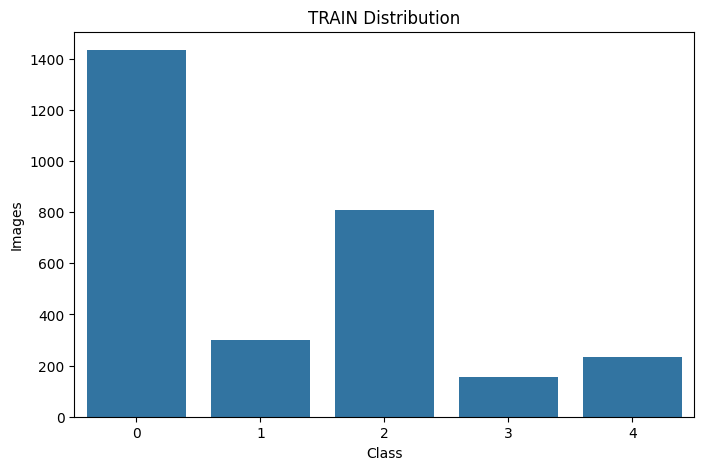


VALIDATION CLASS DISTRIBUTION
Class 0 (No DR): 172 images (46.99%)
Class 1 (Mild): 40 images (10.93%)
Class 2 (Moderate): 104 images (28.42%)
Class 3 (Severe): 22 images (6.01%)
Class 4 (Proliferative DR): 28 images (7.65%)


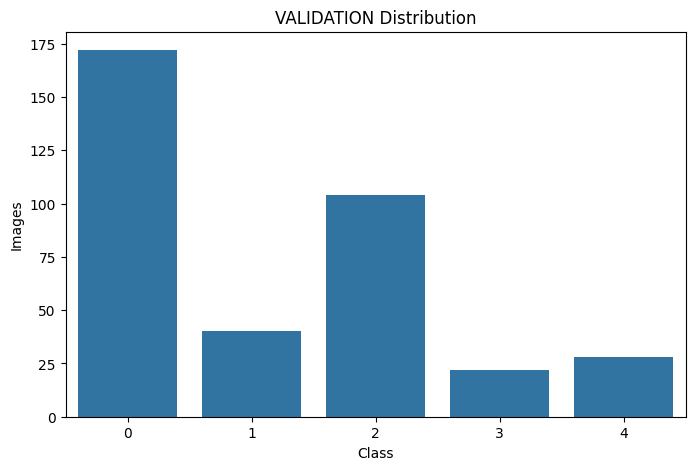


TEST CLASS DISTRIBUTION
Class 0 (No DR): 199 images (54.37%)
Class 1 (Mild): 30 images (8.20%)
Class 2 (Moderate): 87 images (23.77%)
Class 3 (Severe): 17 images (4.64%)
Class 4 (Proliferative DR): 33 images (9.02%)


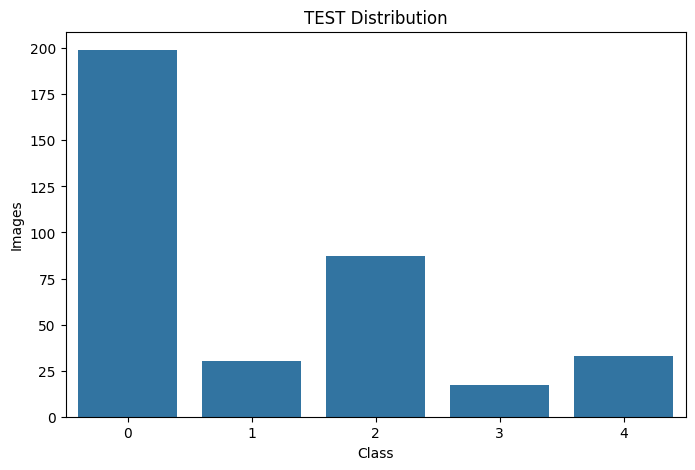


Epoch 1/25


100%|██████████| 23/23 [00:57<00:00,  2.50s/it]



Train Loss : 1.2121
Train Acc  : 0.4935
Val Loss   : 1.2219
Val Acc    : 0.6202
Val F1     : 0.6188
Val Kappa  : 0.4842

Checkpoint Saved: /content/drive/MyDrive/Colab Notebooks/Aptos Checkpoint/best_model.keras

Best model updated!

Epoch 2/25


100%|██████████| 23/23 [00:57<00:00,  2.52s/it]



Train Loss : 0.7698
Train Acc  : 0.6406
Val Loss   : 0.9933
Val Acc    : 0.7213
Val F1     : 0.7262
Val Kappa  : 0.6133

Checkpoint Saved: /content/drive/MyDrive/Colab Notebooks/Aptos Checkpoint/best_model.keras

Best model updated!

Epoch 3/25


...

100%|██████████| 23/23 [00:57<00:00,  2.49s/it]



Train Loss : 0.0793
Train Acc  : 0.9628
Val Loss   : 1.7401
Val Acc    : 0.8388
Val F1     : 0.8324
Val Kappa  : 0.7590

EarlyStopping Counter: 3/5

Epoch 25/25


100%|██████████| 23/23 [00:56<00:00,  2.46s/it]



Train Loss : 0.0819
Train Acc  : 0.9584
Val Loss   : 1.6016
Val Acc    : 0.8415
Val F1     : 0.8378
Val Kappa  : 0.7651

EarlyStopping Counter: 4/5


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 

In [ ]:

# ||=========================================================||
#                           IMPORTS
# ||=========================================================||

import os
import cv2
import random
import numpy as np
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data.sampler import WeightedRandomSampler

import timm

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    cohen_kappa_score
)

import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# CONFIG
# =========================================================

TRAIN_CSV = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/train_1.csv"

VALID_CSV = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/valid.csv"

TEST_CSV = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/test.csv"

TRAIN_DIR = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/train_images/train_images"

VALID_DIR = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/val_images/val_images"

TEST_DIR = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/test_images/test_images"

CHECKPOINT_DIR = "/content/drive/MyDrive/Colab Notebooks/Aptos Checkpoint"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

IMG_SIZE = 384

BATCH_SIZE = 16

EPOCHS = 25

LR = 1e-4

NUM_CLASSES = 5

MODEL_NAME = "efficientnet_b3"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# =========================================================
# SEED
# =========================================================

def seed_everything(seed=42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)

seed_everything()

# =========================================================
# LOAD CSV
# =========================================================

def load_csv(csv_path):

    if not os.path.exists(csv_path):

        raise FileNotFoundError(
            f"CSV NOT FOUND: {csv_path}"
        )

    df = pd.read_csv(csv_path)

    print(f"\nLoaded CSV: {csv_path}")

    return df

# =========================================================
# LOAD IMAGE
# =========================================================

def load_image(image_path):

    image = cv2.imread(image_path)

    if image is None:

        raise FileNotFoundError(
            f"Cannot load image: {image_path}"
        )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    return image

# =========================================================
# VERIFY IMAGES
# =========================================================

def verify_images(df, image_dir, dataset_name):

    print(f"\n{'='*60}")

    print(f"VERIFYING {dataset_name} IMAGES")

    print(f"{'='*60}")

    missing_images = []

    corrupted_images = []

    valid_count = 0

    for idx in tqdm(range(len(df))):

        image_id = df.iloc[idx]['id_code']

        image_path = os.path.join(
            image_dir,
            image_id + ".png"
        )

        if not os.path.exists(image_path):

            missing_images.append(image_path)

            continue

        image = cv2.imread(image_path)

        if image is None:

            corrupted_images.append(image_path)

            continue

        valid_count += 1

    print(f"\nTotal Images     : {len(df)}")

    print(f"Valid Images     : {valid_count}")

    print(f"Missing Images   : {len(missing_images)}")

    print(f"Corrupted Images : {len(corrupted_images)}")

# =========================================================
# CLASS DISTRIBUTION
# =========================================================

def check_class_distribution(df, dataset_name):

    print(f"\n{'='*60}")

    print(f"{dataset_name} CLASS DISTRIBUTION")

    print(f"{'='*60}")

    class_counts = df[
        'diagnosis'
    ].value_counts().sort_index()

    total_images = len(df)

    class_names = {

        0: "No DR",

        1: "Mild",

        2: "Moderate",

        3: "Severe",

        4: "Proliferative DR"
    }

    for class_id, count in class_counts.items():

        percentage = (
            count / total_images
        ) * 100

        print(

            f"Class {class_id} "
            f"({class_names[class_id]}): "
            f"{count} images "
            f"({percentage:.2f}%)"
        )

    plt.figure(figsize=(8,5))

    sns.barplot(

        x=list(class_counts.index),

        y=list(class_counts.values)
    )

    plt.title(
        f"{dataset_name} Distribution"
    )

    plt.xlabel("Class")

    plt.ylabel("Images")

    plt.show()

# =========================================================
# CROP BLACK BORDERS
# =========================================================

def crop_black(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    mask = gray > 10

    if mask.any():

        coords = np.argwhere(mask)

        y0, x0 = coords.min(axis=0)

        y1, x1 = coords.max(axis=0) + 1

        image = image[y0:y1, x0:x1]

    return image

# =========================================================
# CLAHE
# =========================================================

def apply_clahe(image):

    lab = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2LAB
    )

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(

        clipLimit=2.0,

        tileGridSize=(8,8)
    )

    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))

    enhanced = cv2.cvtColor(

        merged,

        cv2.COLOR_LAB2RGB
    )

    return enhanced

# =========================================================
# PREPROCESSING
# =========================================================

def preprocess_fundus(image):

    image = crop_black(image)

    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = apply_clahe(image)

    image = cv2.GaussianBlur(
        image,
        (3,3),
        0
    )

    return image

# =========================================================
# AUGMENTATION
# =========================================================

def get_train_transforms():

    return A.Compose([

        A.HorizontalFlip(p=0.5),

        A.VerticalFlip(p=0.5),

        A.Rotate(
            limit=30,
            p=0.7
        ),

        A.RandomBrightnessContrast(
            brightness_limit=0.2,
            contrast_limit=0.2,
            p=0.5
        ),

        A.Affine(
            scale=(0.9, 1.1),
            translate_percent=(0.05, 0.05),
            rotate=(-20, 20),
            p=0.5
        ),

        A.OneOf([

            A.GaussianBlur(),

            A.MotionBlur(),

            A.MedianBlur()

        ], p=0.3),

        A.CoarseDropout(
            num_holes_range=(1, 8),
            hole_height_range=(8, 32),
            hole_width_range=(8, 32),
            p=0.5
        ),

        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),

        ToTensorV2()

    ])

# =========================================================
# VALIDATION TRANSFORMS
# =========================================================

def get_valid_transforms():

    return A.Compose([

        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        ),

        ToTensorV2()

    ])

# =========================================================
# DATASET
# =========================================================

class APTOSDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        transforms=None
    ):

        self.df = dataframe

        self.image_dir = image_dir

        self.transforms = transforms

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = os.path.join(

            self.image_dir,

            row['id_code'] + ".png"
        )

        image = load_image(image_path)

        image = preprocess_fundus(image)

        if self.transforms:

            image = self.transforms(
                image=image
            )['image']

        return image, row['diagnosis']

# =========================================================
# CREATE DATALOADERS
# =========================================================

def create_dataloaders():

    train_df = load_csv(TRAIN_CSV)

    valid_df = load_csv(VALID_CSV)

    test_df = load_csv(TEST_CSV)


    # CHECK DISTRIBUTION

    check_class_distribution(
        train_df,
        "TRAIN"
    )

    check_class_distribution(
        valid_df,
        "VALIDATION"
    )

    check_class_distribution(
        test_df,
        "TEST"
    )

    # DATASETS

    train_dataset = APTOSDataset(
        train_df,
        TRAIN_DIR,
        get_train_transforms()
    )

    valid_dataset = APTOSDataset(
        valid_df,
        VALID_DIR,
        get_valid_transforms()
    )

    test_dataset = APTOSDataset(
        test_df,
        TEST_DIR,
        get_valid_transforms()
    )

    # HANDLE CLASS IMBALANCE

    class_counts = train_df[
        'diagnosis'
    ].value_counts().sort_index().values

    class_weights = 1. / class_counts

    sample_weights = torch.DoubleTensor([

        class_weights[label]

        for label in train_df['diagnosis']
    ])

    sampler = WeightedRandomSampler(

        sample_weights,

        len(sample_weights)
    )

    # DATALOADERS

    train_loader = DataLoader(

        train_dataset,

        batch_size=BATCH_SIZE,

        sampler=sampler,

        num_workers=2,

        pin_memory=True
    )

    valid_loader = DataLoader(

        valid_dataset,

        batch_size=BATCH_SIZE,

        shuffle=False,

        num_workers=2
    )

    test_loader = DataLoader(

        test_dataset,

        batch_size=BATCH_SIZE,

        shuffle=False,

        num_workers=2
    )

    return (

        train_loader,

        valid_loader,

        test_loader,

        class_weights
    )

# =========================================================
# TRAIN FUNCTION
# =========================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler
):

    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    loop = tqdm(loader)

    for images, labels in loop:

        images = images.to(DEVICE)

        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        loop.set_postfix(
            loss=loss.item()
        )

    train_acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), train_acc

# =========================================================
# EVALUATION FUNCTION
# =========================================================

def evaluate(
    model,
    loader,
    criterion
):

    model.eval()

    total_loss = 0

    all_preds = []

    all_labels = []

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(DEVICE)

            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            total_loss += loss.item()

            preds = torch.argmax(
                outputs,
                dim=1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    acc = accuracy_score(
        all_labels,
        all_preds
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average='weighted'
    )

    kappa = cohen_kappa_score(
        all_labels,
        all_preds
    )

    return (

        total_loss / len(loader),

        acc,

        f1,

        kappa,

        all_preds,

        all_labels
    )

# =========================================================
# SAVE CHECKPOINT
# =========================================================

def save_checkpoint(
    model,
    optimizer,
    epoch,
    best_kappa,
    path
):

    torch.save({

        'epoch': epoch,

        'model_state_dict': model.state_dict(),

        'optimizer_state_dict': optimizer.state_dict(),

        'best_kappa': best_kappa

    }, path)

    print(f"\nCheckpoint Saved: {path}")

# =========================================================
# CONFUSION MATRIX
# =========================================================

def plot_confusion_matrix(
    labels,
    preds
):

    cm = confusion_matrix(
        labels,
        preds
    )

    plt.figure(figsize=(8,6))

    sns.heatmap(

        cm,

        annot=True,

        fmt='d',

        cmap='Blues'
    )

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.title("Confusion Matrix")

    plt.show()

# =========================================================
# MAIN
# =========================================================

def main():

    print("\nUsing Device:", DEVICE)

    # DATALOADERS

    (
        train_loader,
        valid_loader,
        test_loader,
        class_weights

    ) = create_dataloaders()

    # MODEL

    model = timm.create_model(

        MODEL_NAME,

        pretrained=True,

        num_classes=NUM_CLASSES

    ).to(DEVICE)

    # LOSS

    criterion = nn.CrossEntropyLoss(

        weight=torch.FloatTensor(
            class_weights
        ).to(DEVICE)
    )

    # OPTIMIZER

    optimizer = optim.AdamW(

        model.parameters(),

        lr=LR,

        weight_decay=1e-4
    )

    # SCHEDULER

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode='max',

        factor=0.5,

        patience=2
    )

    # MIXED PRECISION

    scaler = torch.amp.GradScaler('cuda')

    # TRACKERS

    best_kappa = 0

    patience = 5

    trigger_times = 0

    train_losses = []

    val_losses = []

    # =====================================================
    # TRAINING LOOP
    # =====================================================

    for epoch in range(EPOCHS):

        print(f"\n{'='*60}")

        print(f"Epoch {epoch+1}/{EPOCHS}")

        print(f"{'='*60}")

        # TRAIN

        train_loss, train_acc = train_one_epoch(

            model,

            train_loader,

            criterion,

            optimizer,

            scaler
        )

        # VALIDATE

        (
            val_loss,
            val_acc,
            val_f1,
            val_kappa,
            _,
            _

        ) = evaluate(

            model,

            valid_loader,

            criterion
        )

        scheduler.step(val_kappa)

        train_losses.append(train_loss)

        val_losses.append(val_loss)

        # PRINT METRICS

        print(f"\nTrain Loss : {train_loss:.4f}")
        print(f"Train Acc  : {train_acc:.4f}")

        print(f"Val Loss   : {val_loss:.4f}")

        print(f"Val Acc    : {val_acc:.4f}")

        print(f"Val F1     : {val_f1:.4f}")

        print(f"Val Kappa  : {val_kappa:.4f}")

        # SAVE BEST MODEL

        if val_kappa > best_kappa:

            best_kappa = val_kappa

            trigger_times = 0

            save_checkpoint(

                model,

                optimizer,

                epoch,

                best_kappa,

                os.path.join(
                    CHECKPOINT_DIR,
                    "best_model.keras"
                )
            )

            print("\nBest model updated!")

        else:

            trigger_times += 1

            print(
                f"\nEarlyStopping Counter: "
                f"{trigger_times}/{patience}"
            )

        # EARLY STOPPING

        if trigger_times >= patience:

            print("\nEarly stopping triggered!")

            break

    # =====================================================
    # LOAD BEST MODEL
    # =====================================================

    checkpoint = torch.load(

        os.path.join(
            CHECKPOINT_DIR,
            "best_model.keras"
        )
    )

    model.load_state_dict(
        checkpoint['model_state_dict']
    )

    print("\nBest model loaded!")

    # =====================================================
    # TESTING
# =====================================================

    (
        test_loss,
        test_acc,
        test_f1,
        test_kappa,
        test_preds,
        test_labels

    ) = evaluate(

        model,

        test_loader,

        criterion
    )

    # FINAL RESULTS

    print(f"\n{'='*60}")

    print("FINAL TEST RESULTS")

    print(f"{'='*60}")

    print(f"\nTest Loss   : {test_loss:.4f}")

    print(f"Test Acc    : {test_acc:.4f}")

    print(f"Test F1     : {test_f1:.4f}")

    print(f"Test Kappa  : {test_kappa:.4f}")

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    class_names = [

        "No DR",

        "Mild",

        "Moderate",

        "Severe",

        "Proliferative DR"
    ]

    print(f"\n{'='*60}")

    print("CLASSIFICATION REPORT")

    print(f"{'='*60}")

    print(

        classification_report(

            test_labels,

            test_preds,

            target_names=class_names
        )
    )

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    plot_confusion_matrix(

        test_labels,

        test_preds
    )

    # =====================================================
    # LOSS CURVE
    # =====================================================

    plt.figure(figsize=(8,5))

    plt.plot(
        train_losses,
        label="Train Loss"
    )

    plt.plot(
        val_losses,
        label="Validation Loss"
    )

    plt.xlabel("Epoch")

    plt.ylabel("Loss")

    plt.title("Training Curve")

    plt.legend()

    plt.show()

# =========================================================
# RUN
# =========================================================

if __name__ == "__main__":

    main()


Loaded: /content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/train_1.csv

Loaded: /content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/valid.csv

Loaded: /content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/test.csv

TRAIN CLASS DISTRIBUTION

Total Images: 2930

Class 0 (No DR): 1434 images (48.94%)
Class 1 (Mild): 300 images (10.24%)
Class 2 (Moderate): 808 images (27.58%)
Class 3 (Severe): 154 images (5.26%)
Class 4 (Proliferative DR): 234 images (7.99%)


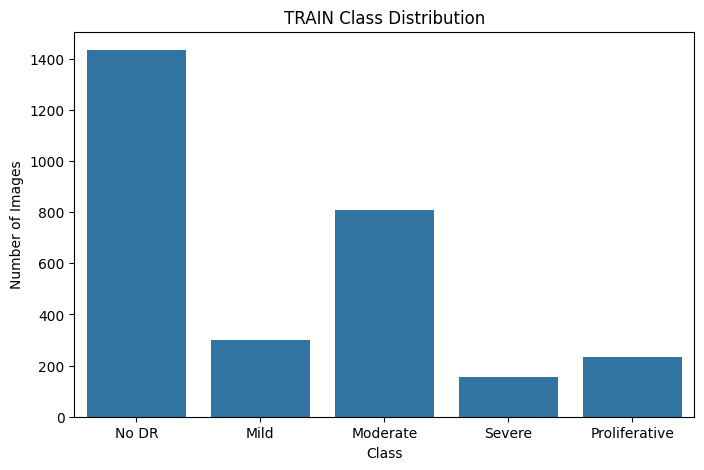


VALIDATION CLASS DISTRIBUTION

Total Images: 366

Class 0 (No DR): 172 images (46.99%)
Class 1 (Mild): 40 images (10.93%)
Class 2 (Moderate): 104 images (28.42%)
Class 3 (Severe): 22 images (6.01%)
Class 4 (Proliferative DR): 28 images (7.65%)


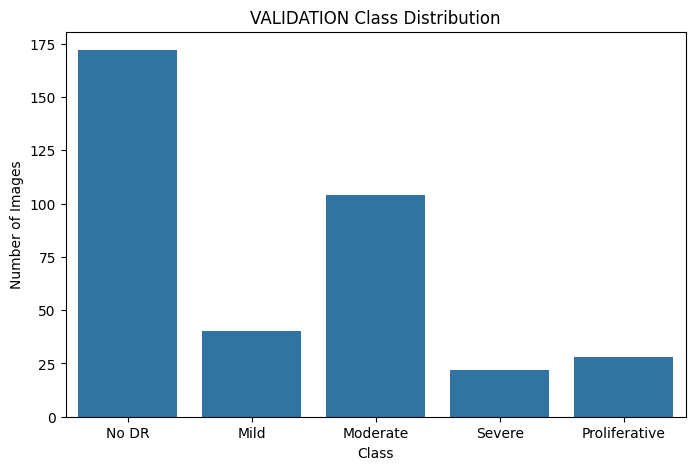


TEST CLASS DISTRIBUTION

Total Images: 366

Class 0 (No DR): 199 images (54.37%)
Class 1 (Mild): 30 images (8.20%)
Class 2 (Moderate): 87 images (23.77%)
Class 3 (Severe): 17 images (4.64%)
Class 4 (Proliferative DR): 33 images (9.02%)


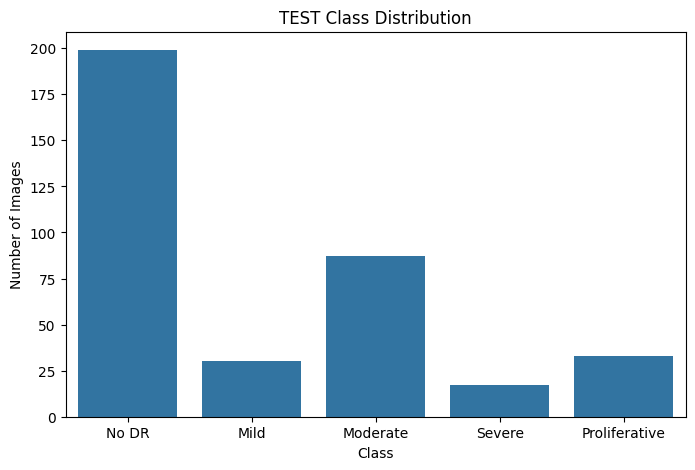

In [ ]:
# =========================================================
# IMPORTS
# =========================================================

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

# =========================================================
# CSV PATHS
# =========================================================

TRAIN_CSV = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/train_1.csv"

VALID_CSV = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/valid.csv"

TEST_CSV = "/content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/test.csv"

# =========================================================
# LOAD CSV FUNCTION
# =========================================================

def load_csv(csv_path):

    df = pd.read_csv(csv_path)

    print(f"\nLoaded: {csv_path}")

    return df

# =========================================================
# CLASS DISTRIBUTION FUNCTION
# =========================================================

def check_class_distribution(df, dataset_name):

    print(f"\n{'='*50}")

    print(f"{dataset_name} CLASS DISTRIBUTION")

    print(f"{'='*50}")

    # COUNT CLASSES
    class_counts = df['diagnosis'].value_counts().sort_index()

    # CLASS NAMES
    class_names = {
        0: "No DR",
        1: "Mild",
        2: "Moderate",
        3: "Severe",
        4: "Proliferative DR"
    }

    total_images = len(df)

    print(f"\nTotal Images: {total_images}\n")

    for class_id, count in class_counts.items():

        percentage = (count / total_images) * 100

        print(
            f"Class {class_id} "
            f"({class_names[class_id]}): "
            f"{count} images "
            f"({percentage:.2f}%)"
        )

    # =====================================================
    # PLOT BAR GRAPH
    # =====================================================

    plt.figure(figsize=(8,5))

    sns.barplot(
        x=list(class_counts.index),
        y=list(class_counts.values)
    )

    plt.title(
        f"{dataset_name} Class Distribution"
    )

    plt.xlabel("Class")

    plt.ylabel("Number of Images")

    plt.xticks(
        ticks=[0,1,2,3,4],
        labels=[
            "No DR",
            "Mild",
            "Moderate",
            "Severe",
            "Proliferative"
        ]
    )

    plt.show()

# =========================================================
# MAIN FUNCTION
# =========================================================

def main():

    # LOAD CSV FILES

    train_df = load_csv(TRAIN_CSV)

    valid_df = load_csv(VALID_CSV)

    test_df = load_csv(TEST_CSV)

    # CHECK DISTRIBUTION

    check_class_distribution(
        train_df,
        "TRAIN"
    )

    check_class_distribution(
        valid_df,
        "VALIDATION"
    )

    check_class_distribution(
        test_df,
        "TEST"
    )

# =========================================================
# RUN
# =========================================================

if __name__ == "__main__":

    main()

Successfully loaded best model from training checkpoint.
Model architecture saved: /content/drive/MyDrive/Colab Notebooks/Aptos Checkpoint/model_architecture.txt

Loaded: /content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/train_1.csv

Loaded: /content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/valid.csv

Loaded: /content/drive/MyDrive/Colab Notebooks/APTOS 2019 DATASET/test.csv

TRAIN CLASS DISTRIBUTION

Total Images: 2930

Class 0 (No DR): 1434 images (48.94%)
Class 1 (Mild): 300 images (10.24%)
Class 2 (Moderate): 808 images (27.58%)
Class 3 (Severe): 154 images (5.26%)
Class 4 (Proliferative DR): 234 images (7.99%)


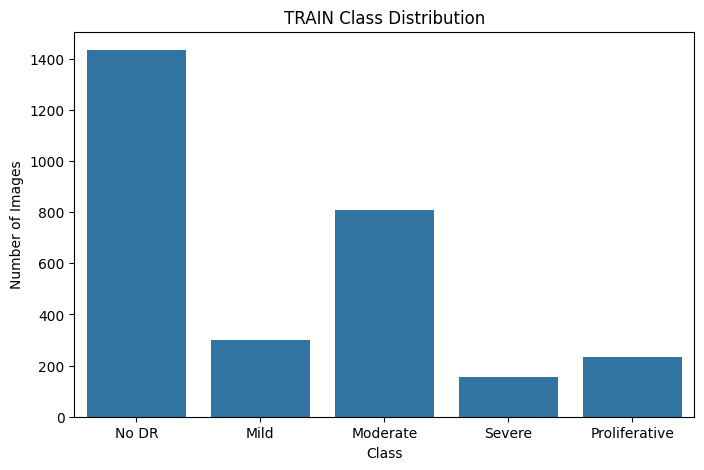


VALIDATION CLASS DISTRIBUTION

Total Images: 366

Class 0 (No DR): 172 images (46.99%)
Class 1 (Mild): 40 images (10.93%)
Class 2 (Moderate): 104 images (28.42%)
Class 3 (Severe): 22 images (6.01%)
Class 4 (Proliferative DR): 28 images (7.65%)


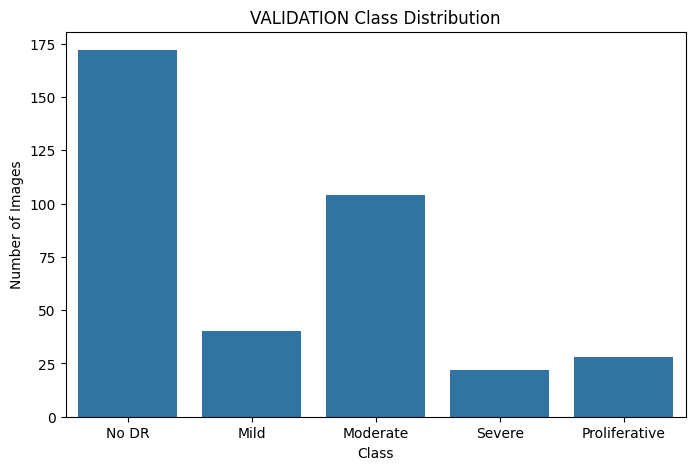


TEST CLASS DISTRIBUTION

Total Images: 366

Class 0 (No DR): 199 images (54.37%)
Class 1 (Mild): 30 images (8.20%)
Class 2 (Moderate): 87 images (23.77%)
Class 3 (Severe): 17 images (4.64%)
Class 4 (Proliferative DR): 33 images (9.02%)


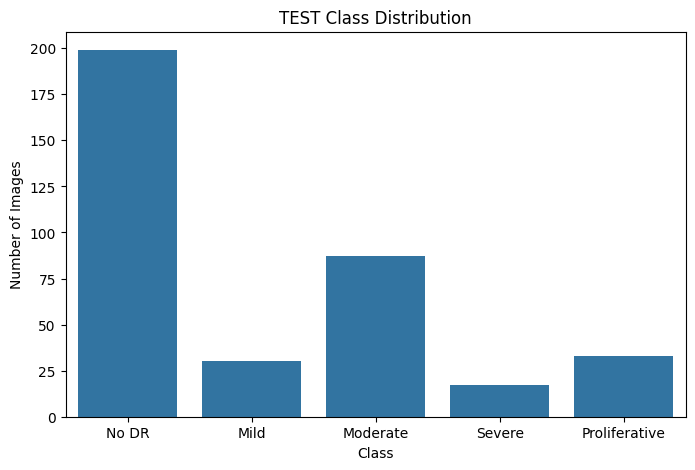


Generating detailed reports for validation set...


100%|██████████| 23/23 [00:56<00:00,  2.44s/it]


CSV Report saved: /content/drive/MyDrive/Colab Notebooks/Aptos Checkpoint/validation_report.csv
Confusion Matrix image saved: /content/drive/MyDrive/Colab Notebooks/Aptos Checkpoint/validation_confusion_matrix.png

Generating detailed reports for test set...


100%|██████████| 23/23 [02:12<00:00,  5.76s/it]


CSV Report saved: /content/drive/MyDrive/Colab Notebooks/Aptos Checkpoint/test_report.csv
Confusion Matrix image saved: /content/drive/MyDrive/Colab Notebooks/Aptos Checkpoint/test_confusion_matrix.png


In [ ]:
# =========================================================
# EXPORT MODEL ARCHITECTURE AND FINAL EVALUATION REPORTS
# =========================================================

import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. PATH TO THE BEST MODEL SAVED BY YOUR TRAINING CELL
checkpoint_path = os.path.join(CHECKPOINT_DIR, "best_model.keras")

if os.path.exists(checkpoint_path):
    # Re-initialize model architecture
    model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES).to(DEVICE)

    # Load the state dict from your existing checkpoint
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"Successfully loaded best model from training checkpoint.")

    # 2. SAVE MODEL ARCHITECTURE TO TEXT FILE
    arch_file = os.path.join(CHECKPOINT_DIR, "model_architecture.txt")
    with open(arch_file, "w") as f:
        f.write(str(model))
    print(f"Model architecture saved: {arch_file}")

    # 3. RUN FINAL EVALUATION ON VALIDATION AND TEST DATA
    # create_dataloaders returns (train_loader, valid_loader, test_loader, class_weights)
    _, valid_loader, test_loader, _ = create_dataloaders()

    datasets = [("validation", valid_loader), ("test", test_loader)]

    for name, loader in datasets:
        print(f"\nGenerating detailed reports for {name} set...")
        _, acc, f1, kappa, preds, labels = evaluate(model, loader, torch.nn.CrossEntropyLoss())

        # 4. SAVE CLASSIFICATION REPORT AS CSV
        report = classification_report(labels, preds, target_names=["No DR", "Mild", "Moderate", "Severe", "Proliferative"], output_dict=True)
        df_report = pd.DataFrame(report).transpose()
        csv_path = os.path.join(CHECKPOINT_DIR, f"{name}_report.csv")
        df_report.to_csv(csv_path)
        print(f"CSV Report saved: {csv_path}")

        # 5. SAVE CONFUSION MATRIX AS PNG
        plt.figure(figsize=(10, 8))
        cm = confusion_matrix(labels, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=["No DR", "Mild", "Moderate", "Severe", "Proliferative"],
                    yticklabels=["No DR", "Mild", "Moderate", "Severe", "Proliferative"])
        plt.title(f"Confusion Matrix - {name.capitalize()}")
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        img_path = os.path.join(CHECKPOINT_DIR, f"{name}_confusion_matrix.png")
        plt.savefig(img_path)
        plt.close()
        print(f"Confusion Matrix image saved: {img_path}")

else:
    print(f"Error: '{checkpoint_path}' not found. Please ensure the training cell has finished and saved the model.")

In [ ]:
# load my model and fine tune this
